`conda activate multi_integration`

# Joint analysis of paired and unpaired multiomic data with scGLUE

## Data preprocessing

In [ ]:
import anndata as ad
import networkx as nx
import scanpy as sc
import pandas as pd
import numpy as np
import muon as mu
import scglue
import os
from matplotlib import rcParams
import matplotlib.pyplot as plt

import seaborn as sns
from itertools import chain
from random import Random

# Import a module with ATAC-seq-related functions
from muon import atac as ac

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/cruiz2/miniconda3/envs/multi_integration/l

In [ ]:
sc.settings.n_jobs = 32

In [ ]:
scglue.plot.set_publication_params()
rcParams["figure.figsize"] = (4, 4)

In [ ]:
import torch

# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available")
    
    # Get the number of available GPUs
    num_gpus = torch.cuda.device_count()
    print(f"Number of available GPUs: {num_gpus}")
    
    # Get the name of each available GPU
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("CUDA is not available")

CUDA is not available


### Preprocess scRNA-seq data

In [ ]:
rna = sc.read('data/rna_dmg_atlas_for_scglue_only_10x.h5ad')
rna.obs['domain'] = 'scRNA-seq'
rna

AnnData object with n_obs × n_vars = 397794 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sampl

In [ ]:
rna.X, rna.X.data

(<397794x19248 sparse matrix of type '<class 'numpy.float64'>'
 	with 835603632 stored elements in Compressed Sparse Column format>,
 array([5., 1., 2., ..., 1., 1., 1.]))

In [ ]:
rna.layers["counts"] = rna.X.copy()

In [ ]:
sc.pp.highly_variable_genes(rna, n_top_genes=2000, flavor="seurat_v3", batch_key='Batch_for_correction')

In [ ]:
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.scale(rna)
sc.tl.pca(rna, n_comps=100, svd_solver="auto")

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


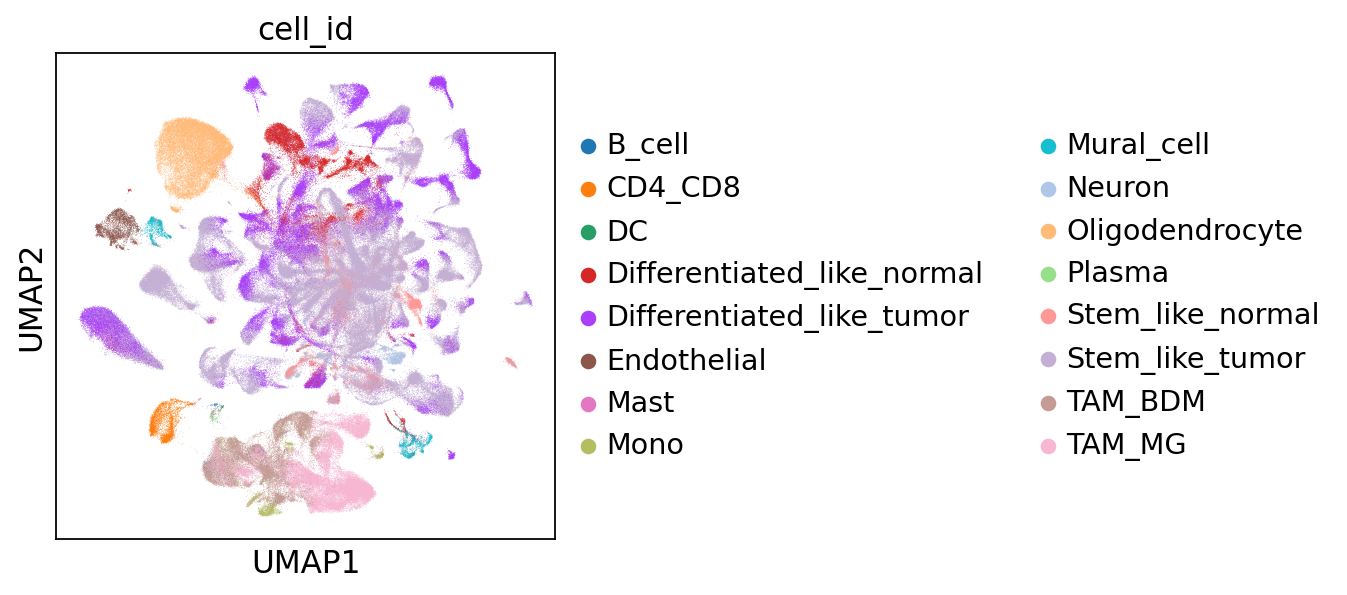

In [ ]:
sc.pp.neighbors(rna, metric="cosine")
sc.tl.umap(rna)
sc.pl.umap(rna, color="cell_id")

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


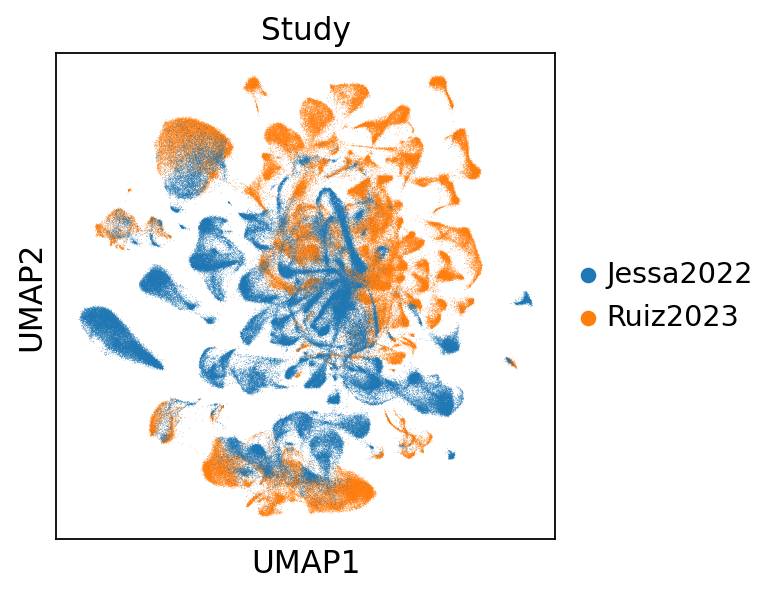

In [ ]:
sc.pl.umap(rna, color="Study")

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


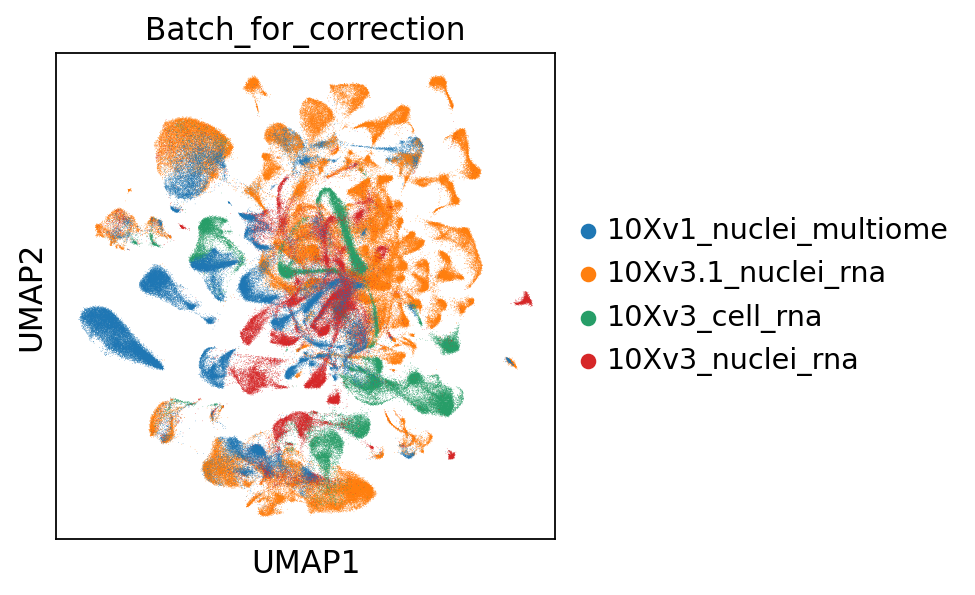

In [ ]:
sc.pl.umap(rna, color="Batch_for_correction")

### Preprocess scATAC-seq data

In [ ]:
adata_atac_multiome = sc.read('data/atac_multi_dmg_atlas_for_scglue.h5ad')
adata_atac_multiome.obs['modality'] = 'multiome'
adata_atac_multiome.obs['domain'] = 'scATAC-seq'
adata_atac_multiome

AnnData object with n_obs × n_vars = 88053 × 378298
    obs: 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'passed_filters', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFi

In [ ]:
adata_atac = sc.read('data/atac_only_dmg_atlas_for_scglue.h5ad')
adata_atac.obs['modality'] = 'atac'
adata_atac.obs['domain'] = 'scATAC-seq'
adata_atac

AnnData object with n_obs × n_vars = 36541 × 378298
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired

In [ ]:
atac = adata_atac.concatenate(adata_atac_multiome, index_unique = None)
atac

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


AnnData object with n_obs × n_vars = 124594 × 378298
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paire

In [ ]:
del adata_atac_multiome
del adata_atac

In [ ]:
atac.var_names

Index(['chr1:9729-10741', 'chr1:15764-16590', 'chr1:17055-17946',
       'chr1:28900-29821', 'chr1:180694-181903', 'chr1:183749-184822',
       'chr1:186326-187493', 'chr1:189036-189904', 'chr1:190943-191933',
       'chr1:264326-265168',
       ...
       'KI270731.1:4432-5400', 'KI270731.1:13182-14236',
       'KI270731.1:14520-15440', 'KI270721.1:2096-2993',
       'KI270721.1:3576-4408', 'KI270721.1:8328-10262',
       'KI270721.1:14172-15021', 'KI270721.1:43767-44670',
       'KI270721.1:46484-47618', 'KI270726.1:13856-14767'],
      dtype='object', length=378298)

In [ ]:
# Save original counts
atac.layers["counts"] = atac.X.copy()

In [ ]:
# https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/pbmc10k/2-Chromatin-Accessibility-Processing.html
ac.pp.tfidf(atac, scale_factor=1e4)

In [ ]:
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


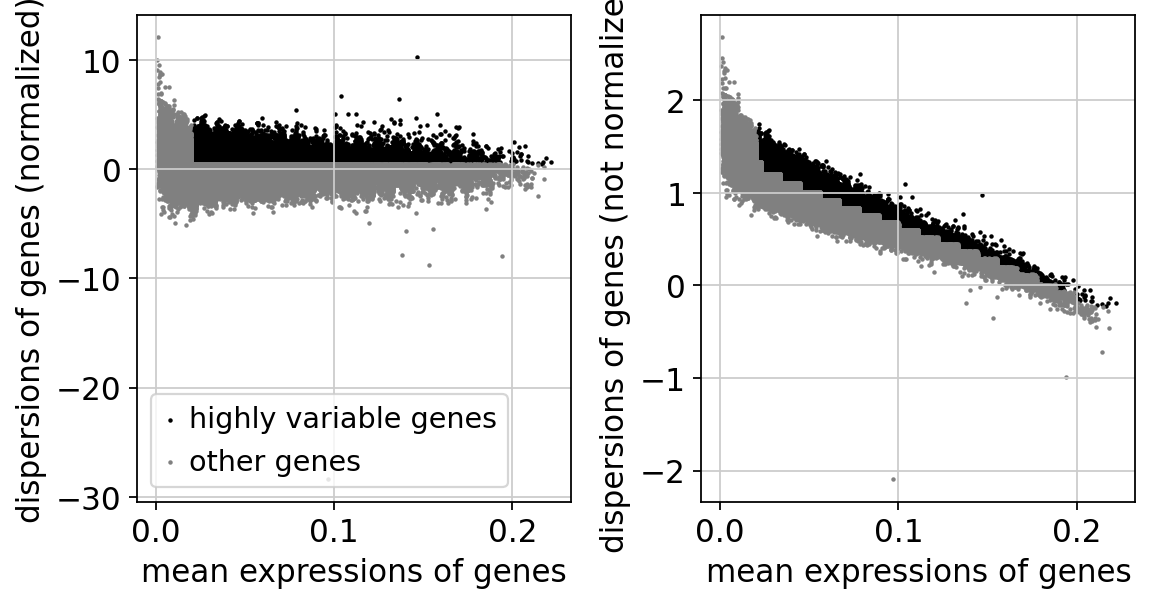

In [ ]:
# https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/pbmc10k/2-Chromatin-Accessibility-Processing.html
sc.pp.highly_variable_genes(atac, min_mean=0.02, min_disp=.5)
sc.pl.highly_variable_genes(atac)

In [ ]:
np.sum(atac.var.highly_variable)

39667

In [ ]:
atac.X, atac.X.data

(<124594x378298 sparse matrix of type '<class 'numpy.float64'>'
 	with 767382394 stored elements in Compressed Sparse Row format>,
 array([0.61499066, 0.36141788, 0.59841456, ..., 1.01215117, 0.76451196,
        0.94468261]))

In [ ]:
# after performing the selection of highly variable peaks, we revert adata.X back to raw counts

atac.X = atac.layers["counts"].copy()
atac.X, atac.X.data

(<124594x378298 sparse matrix of type '<class 'numpy.float64'>'
 	with 767382394 stored elements in Compressed Sparse Row format>,
 array([2., 1., 1., ..., 1., 1., 1.]))

In [ ]:
scglue.data.lsi(atac, n_components=101, n_iter=20, use_highly_variable = True)

In [ ]:
# https://github.com/theislab/epicardiods_analysis/blob/main/notebooks/scglue_unfiltered.ipynb
# remove first column as it is normally correlated with seq depth
atac.obsm['X_lsi'] = atac.obsm['X_lsi'][:, 1:]

In [ ]:
sc.pp.neighbors(atac, use_rep="X_lsi", metric="cosine")
sc.tl.umap(atac)

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


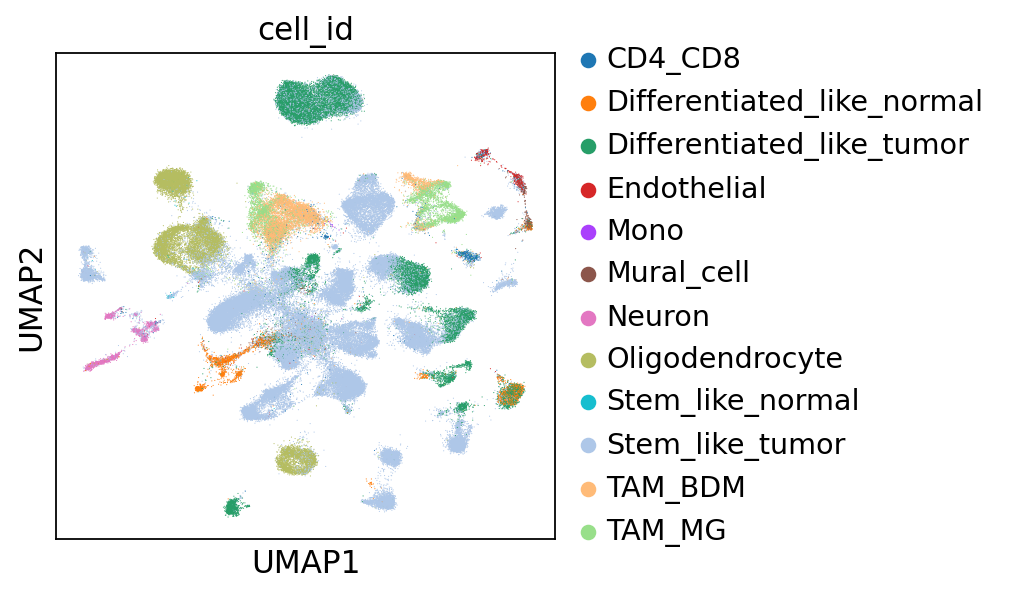

In [ ]:
sc.pl.umap(atac, color="cell_id")

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


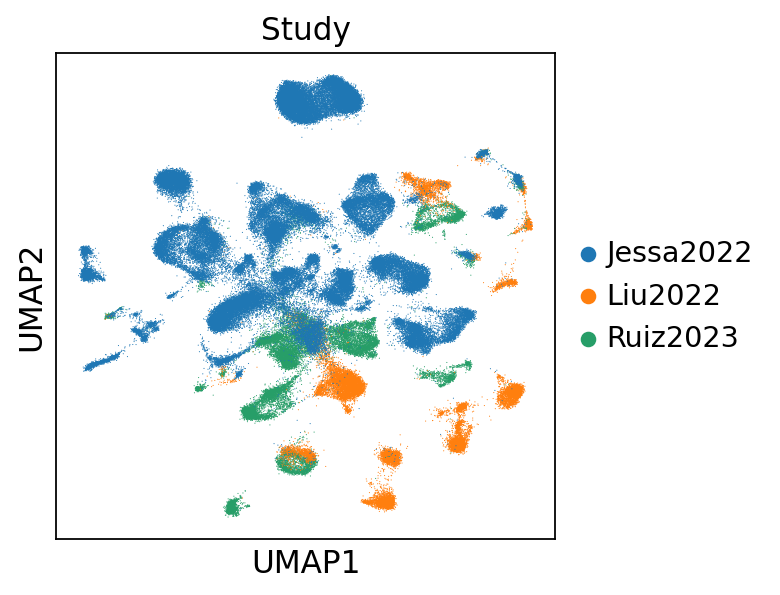

In [ ]:
sc.pl.umap(atac, color="Study")

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


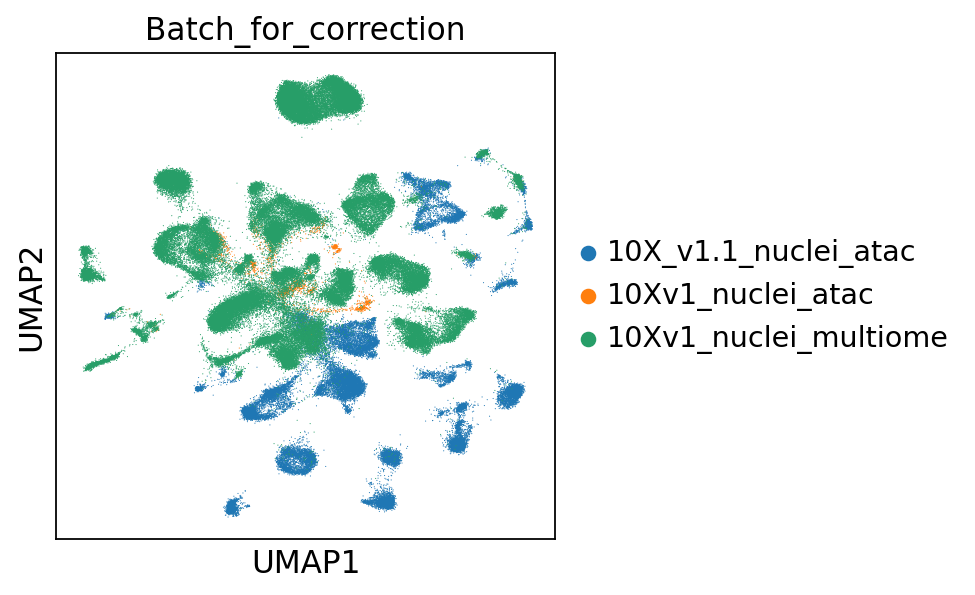

In [ ]:
sc.pl.umap(atac, color="Batch_for_correction")

## Construct prior regulatory graph

### Obtain genomic coordinates

In [ ]:
rna.var.head()

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,mean,std
A1BG,0.631716,1202.719885,373.474371,3.220355,True,False,NaN,0.075939,0.115226,0.846946,0,0.032407,0.154903
A1CF,0.068691,39.460411,37.081347,1.064158,False,False,NaN,0.003132,0.004666,1.026658,0,0.001720,0.040852
A2M,5.611721,15361.999192,7507.142953,2.046318,False,True,979.0,0.927028,13.872979,2.551698,4,0.262140,0.560820
A2ML1,0.252424,449.444287,142.899698,3.138113,True,False,NaN,0.044244,0.105158,1.229011,0,0.020566,0.137915
A3GALT2,0.042899,6.267352,22.382860,0.280007,False,False,NaN,0.007642,0.008403,0.753766,0,0.004032,0.058262


In [ ]:
scglue.data.get_gene_annotation(
    rna, gtf="/home/cruiz2/software/refdata-gex-GRCh38-2020-A/genes/genes.gtf",
    gtf_by="gene_name"
)
rna.var.loc[:, ["chrom", "chromStart", "chromEnd"]].head()

,chrom,chromStart,chromEnd
A1BG,chr19,58345177,58353492
A1CF,chr10,50799408,50885675
A2M,chr12,9067663,9116229
A2ML1,chr12,8822620,8887001
A3GALT2,chr1,33306765,33321098


In [ ]:
split = atac.var_names.str.split(r"[:-]")
atac.var["chrom"] = split.map(lambda x: x[0])
atac.var["chromStart"] = split.map(lambda x: x[1]).astype(int)
atac.var["chromEnd"] = split.map(lambda x: x[2]).astype(int)
atac.var.head()

,count-0,percentile-0,count-1,percentile-1,highly_variable,means,dispersions,dispersions_norm,chrom,chromStart,chromEnd
chr1:9729-10741,172.0,0.161196,2819.0,0.895580,True,0.047337,1.225940,2.544523,chr1,9729,10741
chr1:15764-16590,58.0,0.008504,213.0,0.013661,False,0.005316,1.624261,2.139632,chr1,15764,16590
chr1:17055-17946,97.0,0.029141,282.0,0.042593,False,0.006867,1.409761,0.125978,chr1,17055,17946
chr1:28900-29821,24.0,0.001927,334.0,0.083289,False,0.007275,1.583779,1.759601,chr1,28900,29821
chr1:180694-181903,1007.0,0.850877,6541.0,0.960145,True,0.103682,1.090948,6.731893,chr1,180694,181903


In [ ]:
directory = "mosaic_integration_scglue/"

# Check if the directory exists
if not os.path.exists(directory):
    # Create the directory if it doesn't exist
    os.makedirs(directory)

# Perform your file operations
rna.write(os.path.join(directory, "rna-pp-2k-hvg.h5ad"), compression="gzip")
atac.write(os.path.join(directory, "atac-pp-40k-hvp.h5ad"), compression="gzip")